# **Analisis Sentimen Masyarakat terhadap Program Makan Bergizi Gratis Berdasarkan Komentar YouTube**

# Install Library

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.2 MB/s eta 0:00:00


In [ ]:
!pip install transformers torch

# Import Library

In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
import nltk
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
import string
import nltk
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
import nltk
from nltk.corpus import stopwords as nltk_stopwords

nltk.download('punkt')
nltk.download('stopwords')

stopword_id = set(nltk_stopwords.words('indonesian'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Read Data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/dzulfi02/BLKPP-Data-Analis/main/Mentoring/Dataset/mbgscrapping.csv')

In [ ]:
df

,cid,text,time,author,channel,votes,replies,photo,heart,reply,time_parsed,video_url,paid
0,UgxokclGBDxsTOqz-XR4AaABAg,Tiba masanya Sumatra berpisah dr Indonesia ker...,07-07-2026 23:35:47,@deandin3068,UCQvSdkDKNfjU3Eqo7p2llZw,0,NaN,https://yt3.ggpht.com/ytc/AIdro_lxy2NXNyBgDZbw...,False,False,1.783467e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,NaN
1,UgznI1mbhj8G8Mkmo4t4AaABAg,11:16 beliau mengutamakan muridnya menjadi ba...,05-07-2026 02:35:47,@KuchoengNyudae,UCeMKvFL929jDmZdQsohJWVw,0,NaN,https://yt3.ggpht.com/ytc/AIdro_m-Whn0Wjn4D0JT...,False,False,1.783219e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,NaN
2,UgysLjO9gDxSdSGsPAN4AaABAg,pasti ada pihak 3 yg memberikan racun utk menj...,04-07-2026 02:35:47,@Ammarbm-rx4zw,UCBzqS8B0Wznjexn72uLKDbg,0,NaN,https://yt3.ggpht.com/ytc/AIdro_meYAh6NPkc3qZ9...,False,False,1.783133e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,NaN
3,Ugxmn111o_y5ASKsoEt4AaABAg,Ngeriii ya pengajar digajih sedikit.pegawai MB...,02-07-2026 02:35:47,@SuhaeliParid-sq8wn,UCpPr-5-Esm5OGtzajFQ67Lg,0,NaN,https://yt3.ggpht.com/ytc/AIdro_nn2r27xgt-QLsA...,False,False,1.782960e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,NaN
4,UgzMImGEf8PsgIY2OFx4AaABAg,MBG Mas Bwahlil Genteng,30-06-2026 02:35:47,@xiaoling6867,UCMCuwwCIBgLJymsn9jCd6fw,0,NaN,https://yt3.ggpht.com/ytc/AIdro_nW6zUsPmvIJJvJ...,False,False,1.782787e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6547,UgzVD7PdZ3sanMt6Hzx4AaABAg.AH4KnBO4IfBAH5gyJQRKQl,memang menyuarakan kebenaran tapi kebenarana y...,08-07-2025 02:37:56,@yosurekusi,UCeWFI34qGgzFI1YuRqCAMlw,0,NaN,https://yt3.ggpht.com/bNZH0G6foVRwNUiY76_VYTHh...,False,True,1.751942e+09,https://www.youtube.com/watch?v=a2WXt0aW76g,NaN
6548,UgxyOaNXXockNIgIj-14AaABAg.AH4GG-E_4cjAH4kSi7HE7N,Sependapat,08-07-2025 02:37:56,@tegarjaya2676,UCk5oTW8B5zDnWHFk34Je3Rg,3,NaN,https://yt3.ggpht.com/ytc/AIdro_ltGlb3_7X3ZrEV...,False,True,1.751942e+09,https://www.youtube.com/watch?v=a2WXt0aW76g,NaN
6549,UgxyOaNXXockNIgIj-14AaABAg.AH4GG-E_4cjAH4sgSRW_oC,10 tahun???\nsejak 1998 melarikan diri ke Yord...,08-07-2025 02:37:56,@munif4U,UCwg9iajpOPrV6L4Ws-j06uA,3,NaN,https://yt3.ggpht.com/ytc/AIdro_mOIVumxYu5KmL5...,False,True,1.751942e+09,https://www.youtube.com/watch?v=a2WXt0aW76g,NaN
6550,UgxyOaNXXockNIgIj-14AaABAg.AH4GG-E_4cjAH4tV554ax2,​ @munif4U ohhh jd beliu ini termasuk salah s...,08-07-2025 02:37:56,@EnglaFebryo,UC1hy9nm5WLlimS7i_rmcRPA,4,NaN,https://yt3.ggpht.com/ytc/AIdro_nbUdQl7FOlBtH9...,False,True,1.751942e+09,https://www.youtube.com/watch?v=a2WXt0aW76g,NaN


# Data Understanding (EDA Awal)

##Jumlah Data

In [ ]:
df.shape

(6552, 13)

terdapat 6552 komentar yang berhasil di data (scraping) dari comment youtube yang berasal dari dua video berbeda dengan dua channel berbeda. Sumber:
| Link | Judul Video | Channel |
|------|-------------|----------|
| https://www.youtube.com/watch?v=0BRFlBVWH3c | TAK ADA MAKAN SIANG GRATIS : Kelindan Kepentingan di Balik Program MBG | Watchdoc Documentary |
| https://www.youtube.com/watch?v=a2WXt0aW76g | Kroni Prabowo dalam Proyek Makan Bergizi Gratis (MBG) : Bocor Alus Politik | Tempodotco |

##Informasi Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6552 entries, 0 to 6551
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cid          6552 non-null   object 
 1   text         6552 non-null   object 
 2   time         6552 non-null   object 
 3   author       6552 non-null   object 
 4   channel      6552 non-null   object 
 5   votes        6552 non-null   int64  
 6   replies      242 non-null    float64
 7   photo        6552 non-null   object 
 8   heart        6552 non-null   bool   
 9   reply        6552 non-null   bool   
 10  time_parsed  6552 non-null   float64
 11  video_url    6552 non-null   object 
 12  paid         9 non-null      object 
dtypes: bool(2), float64(2), int64(1), object(8)
memory usage: 576.0+ KB


##Missing Value

In [ ]:
df.isnull().sum()

,0
cid,0
text,0
time,0
author,0
channel,0
votes,0
replies,6310
photo,0
heart,0
reply,0


In [ ]:
df['replies'] = df['replies'].fillna(0)

In [ ]:
df['paid'].unique()

array([nan, 'IDR\xa050,000', 'IDR\xa020,000', 'IDR\xa079,000',
       'IDR\xa035,000'], dtype=object)

In [ ]:
df['paid'] = (
    df['paid']
    .fillna('0')
    .str.replace('\xa0', ' ', regex=False)
)

In [ ]:
df.isnull().sum()

,0
cid,0
text,0
time,0
author,0
channel,0
votes,0
replies,0
photo,0
heart,0
reply,0


##Duplicate Data

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['text'].duplicated().sum()

np.int64(231)

In [ ]:
duplicate = df[df.duplicated(subset=['text'], keep=False)]
duplicate

,cid,text,time,author,channel,votes,replies,photo,heart,reply,time_parsed,video_url,paid
49,UgzCw_TdnVUPzgQZKm94AaABAg,😢,08-06-2026 02:35:47,@BocilgagTeloo,UCjbhY41DZYmWmVZ7WYO1D1g,0,0.0,https://yt3.ggpht.com/ytc/AIdro_nYQvAmUyrYtkF2...,False,False,1.780886e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,0
90,UgxsVrHSjRvV7OrXX494AaABAg,.,08-06-2026 02:35:48,@dandisuhendra6409,UCJmOrdonkYj4gH27-Pq9NbQ,0,0.0,https://yt3.ggpht.com/ytc/AIdro_m5tGpcMYOqsv44...,False,False,1.780886e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,0
171,UgwdLqxN0Yp9iJhUlOp4AaABAg,lu bayangin dah nanti 2029 petugas sppg disuru...,08-05-2026 02:35:49,@kamils05,UCchiv-d7tm8tzafl3REJuXA,0,0.0,https://yt3.ggpht.com/fxfpkpGKPIqQfJabMR0-EhlA...,False,False,1.778208e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,0
172,UgzbxCERJLgOF-CkIUx4AaABAg,lu bayangin dah nanti 2029 petugas sppg disuru...,08-05-2026 02:35:49,@kamils05,UCchiv-d7tm8tzafl3REJuXA,0,0.0,https://yt3.ggpht.com/fxfpkpGKPIqQfJabMR0-EhlA...,False,False,1.778208e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,0
219,Ugz7V3P4hYPFjSA97HF4AaABAg,Semoga Tuhan memberkati untuk bisa mewujudkan ...,08-04-2026 02:35:50,@farizddam8488,UCpfQVTRjsgEIMmK41ZYtutw,0,0.0,https://yt3.ggpht.com/ytc/AIdro_l6OMZmxVIL2TM6...,False,False,1.775616e+09,https://www.youtube.com/watch?v=0BRFlBVWH3c,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6519,UgwPYdiPZH4DWAeyHFJ4AaABAg.AH4mQokYldBAH5jzDaqUzm,​ @Ninety_4 lha...ini yg fitnah muncul...,08-07-2025 02:37:55,@lirafauzi4770,UCQFoUXf4Mwle5PoyJE36SFw,0,0.0,https://yt3.ggpht.com/ytc/AIdro_m0TWGDJ1pPXYKd...,False,True,1.751942e+09,https://www.youtube.com/watch?v=a2WXt0aW76g,0
6520,UgwPYdiPZH4DWAeyHFJ4AaABAg.AH4mQokYldBAH7DGweoU9r,Beras & migor dh habis? ​ @Ninety_4,08-07-2025 02:37:55,@m.yasser1322,UCuOmX0dfQPcopX_aOFKQL5w,0,0.0,https://yt3.ggpht.com/ytc/AIdro_mTNh5wAqpjxAa7...,False,True,1.751942e+09,https://www.youtube.com/watch?v=a2WXt0aW76g,0
6525,UgzUmLkeKcs8i5A5h-94AaABAg,🔥,08-07-2025 02:37:55,@Surya-Lusi,UCE6_hc8YnT6ib8ppFZLz8Qg,1,0.0,https://yt3.ggpht.com/ytc/AIdro_m0roUxwatvB5rg...,False,False,1.751942e+09,https://www.youtube.com/watch?v=a2WXt0aW76g,0
6543,UgzVD7PdZ3sanMt6Hzx4AaABAg.AH4KnBO4IfBAH5jrT2q-ES,"Sabar ya, bang\nB4b1 b4b1 mulyono mulai berkel...",08-07-2025 02:37:56,@gusaguschanel,UCZMmYM-OO2XAGbIJOCt9IJA,3,0.0,https://yt3.ggpht.com/H8Np2W9QP70U5fkSJbmcvAaB...,False,True,1.751942e+09,https://www.youtube.com/watch?v=a2WXt0aW76g,0


In [ ]:
df = df.drop_duplicates(subset='text').reset_index(drop=True)

In [ ]:
df.shape

(6321, 13)

##Statistik Deskriptif

In [ ]:
df.describe()

,votes,replies,time_parsed
count,6321.000000,6321.000000,6.321000e+03
mean,4.590097,0.210252,1.759966e+09
std,54.713354,2.608821,1.001310e+07
min,0.000000,0.000000,1.751942e+09
25%,0.000000,0.000000,1.751942e+09
50%,0.000000,0.000000,1.751942e+09
75%,0.000000,0.000000,1.767840e+09
max,2480.000000,96.000000,1.783467e+09


##Distribusi Data

In [ ]:
#melihat jumlah komentar di setiap video
df['video_url'].value_counts()

,count
video_url,
https://www.youtube.com/watch?v=a2WXt0aW76g,4427
https://www.youtube.com/watch?v=0BRFlBVWH3c,1894


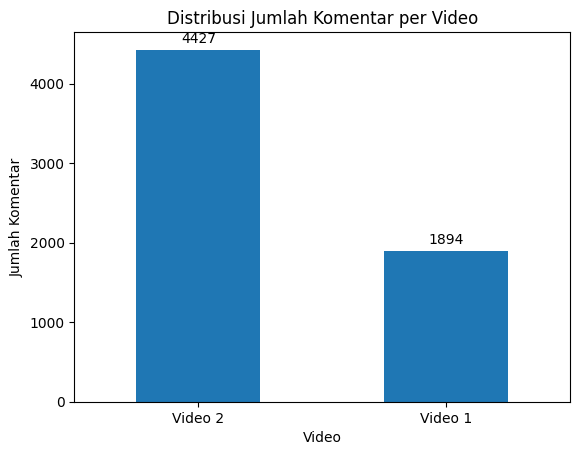

In [ ]:
import matplotlib.pyplot as plt

df['video'] = df['video_url'].replace({
    'https://www.youtube.com/watch?v=0BRFlBVWH3c': 'Video 1',
    'https://www.youtube.com/watch?v=a2WXt0aW76g': 'Video 2'
})

ax = df['video'].value_counts().plot(kind='bar')

plt.title('Distribusi Jumlah Komentar per Video')
plt.xlabel('Video')
plt.ylabel('Jumlah Komentar')
plt.xticks(rotation=0)
ax.bar_label(ax.containers[0], padding=3)

plt.show()

#Data Preprocessing

In [ ]:
df = df[['text']].copy()

##Cleaning

In [ ]:
def cleaning(text):

    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus hashtag
    text = re.sub(r'#\w+', '', text)

    # ganti titik menjadi spasi
    text = text.replace('.', ' ')

    # ganti underscore
    text = text.replace('_', ' ')

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus emoji
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        '',
        text,
        flags=re.UNICODE
    )

    # hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # Menghapus karakter non-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')

    # Menghapus newline dan tab
    text = text.replace('\n', ' ').replace('\t', ' ')

    return text

df['cleaning'] = df['text'].apply(cleaning)

## Case Folding

In [ ]:
def case_folding(text):
  if isinstance(text, str):
    lowercase_text = text.lower()
    return lowercase_text
  else:
    return text
df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(10)

,text,cleaning,case_folding
0,Tiba masanya Sumatra berpisah dr Indonesia ker...,Tiba masanya Sumatra berpisah dr Indonesia ker...,tiba masanya sumatra berpisah dr indonesia ker...
1,11:16 beliau mengutamakan muridnya menjadi ba...,beliau mengutamakan muridnya menjadi baik dahu...,beliau mengutamakan muridnya menjadi baik dahu...
2,pasti ada pihak 3 yg memberikan racun utk menj...,pasti ada pihak yg memberikan racun utk menjat...,pasti ada pihak yg memberikan racun utk menjat...
3,Ngeriii ya pengajar digajih sedikit.pegawai MB...,Ngeriii ya pengajar digajih sedikit pegawai MB...,ngeriii ya pengajar digajih sedikit pegawai mb...
4,MBG Mas Bwahlil Genteng,MBG Mas Bwahlil Genteng,mbg mas bwahlil genteng
5,Dzolimnya penguasa 😢😢,Dzolimnya penguasa,dzolimnya penguasa
6,"chanel George Soros, benci lihat indonesia ken...",chanel George Soros benci lihat indonesia keny...,chanel george soros benci lihat indonesia keny...
7,Nak pada bawa bekal dari rumah itu layak dimak...,Nak pada bawa bekal dari rumah itu layak dimak...,nak pada bawa bekal dari rumah itu layak dimak...
8,lengserkan Prabowo segera,lengserkan Prabowo segera,lengserkan prabowo segera
9,"""hanya"", sebegitu ga pentingkah nyawa 200 oran...",hanya sebegitu ga pentingkah nyawa orang yang ...,hanya sebegitu ga pentingkah nyawa orang yang ...


## Tokenize

In [ ]:
def tokenize(text):
  tokens = text.split()
  return tokens
df['tokenize'] = df['case_folding'].apply(tokenize)
df.head()

,text,cleaning,case_folding,tokenize
0,Tiba masanya Sumatra berpisah dr Indonesia ker...,Tiba masanya Sumatra berpisah dr Indonesia ker...,tiba masanya sumatra berpisah dr indonesia ker...,"[tiba, masanya, sumatra, berpisah, dr, indones..."
1,11:16 beliau mengutamakan muridnya menjadi ba...,beliau mengutamakan muridnya menjadi baik dahu...,beliau mengutamakan muridnya menjadi baik dahu...,"[beliau, mengutamakan, muridnya, menjadi, baik..."
2,pasti ada pihak 3 yg memberikan racun utk menj...,pasti ada pihak yg memberikan racun utk menjat...,pasti ada pihak yg memberikan racun utk menjat...,"[pasti, ada, pihak, yg, memberikan, racun, utk..."
3,Ngeriii ya pengajar digajih sedikit.pegawai MB...,Ngeriii ya pengajar digajih sedikit pegawai MB...,ngeriii ya pengajar digajih sedikit pegawai mb...,"[ngeriii, ya, pengajar, digajih, sedikit, pega..."
4,MBG Mas Bwahlil Genteng,MBG Mas Bwahlil Genteng,mbg mas bwahlil genteng,"[mbg, mas, bwahlil, genteng]"


## Normalisasi Slang

In [ ]:
slang_dict = {
    'yg':'yang',
    'dg':'dengan',
    'dgn':'dengan',
    'bgn' :'bangun',
    'utk':'untuk',
    'sdh':'sudah',
    'udh':'sudah',
    'udah':'sudah',
    'blm':'belum',
    'sm':'sama',
    'krn':'karena',
    'dr':'dari',
    'trs':'terus',
    'lu' : 'kamu',
    'loe' : 'kamu',
    'dpt':'dapat',
    'dapet':'dapat',
    'bkn':'bukan',
    'jd':'jadi',
    'jdi':'jadi',
    'bwt':'buat',
    'byr':'bayar',
    'pke':'pakai',
    'pkai':'pakai',
    'org':'orang',
    'ank':'anak',
    'ortu':'orang tua',
    'mrk':'mereka',
    'sy':'saya',
    'sya':'saya',
    'gw':'saya',
    'gua':'saya',
    'gue':'saya',
    'aq':'aku',
    'gk':'tidak',
    'ga':'tidak',
    'gak':'tidak',
    'nggak':'tidak',
    'ngga':'tidak',
    'enggak':'tidak',
    'tdk':'tidak',
    'bgt':'banget',
    'bngt':'banget',
    'bnget':'banget',
    'jgn':'jangan',
    'jngn':'jangan',
    'hr':'hari',
    'hri':'hari',
    'thn':'tahun',
    'bln':'bulan',
    'byk':'banyak',
    'bnyk':'banyak',
    'sdkt':'sedikit',
    'mnrt':'menurut',
    'pdhl':'padahal',
    'klu':'kalau',
    'kalo':'kalau',
    'klo':'kalau',
    'kl':'kalau',
    'tp':'tapi',
    'tpi':'tapi',
    'bs':'bisa',
    'bsa':'bisa',
    'aja':'saja',
    'doang':'saja',
    'smoga':'semoga',
    'moga':'semoga',
    'kyk':'seperti',
    'cm':'cuma',
    'cmn':'cuma',
    'mbg' : 'makan bergizi gratis',
    # politik & sosial
    'rkyt':'rakyat',
    'masyrkt':'masyarakat',
    'pemrintah':'pemerintah',
    'pmrintah':'pemerintah',
    'bpk':'bapak',
    'pak':'bapak',
    'bu':'ibu',
    'uu' : 'undang undang'
}

def normalize_slang(tokens):

    return [
        slang_dict[word] if word in slang_dict else word
        for word in tokens
    ]

df['normalize'] = df['tokenize'].apply(normalize_slang)

## Stopword Removal

In [ ]:
custom_stopwords = {'yg', 'aja', 'nya', 'sih', 'nih', 'dong', 'lah',
                    'mah', 'kok', 'gak', 'ga',
                    'nggak', 'udah', 'sdh', 'bgt', 'banget'}
stopword_id.update(custom_stopwords)
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopword_id]

df['stopword'] = df['normalize'].apply(remove_stopwords)

## Stemming Bahasa Indonesia

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

cache = {}

def stemming(tokens):
    hasil = []
    for kata in tokens:
        if kata not in cache:
            cache[kata] = stemmer.stem(kata)
        hasil.append(cache[kata])
    return ' '.join(hasil)

df['stemming'] = df['stopword'].apply(stemming)

# Sentiment Labeling (IndoBERT)

In [35]:
classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    )

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [36]:
classifier("program ini sangat bagus")

[{'label': 'positive', 'score': 0.9949416518211365}]

In [38]:
labels = []
scores = []

for text in df['stemming']:

    if pd.notnull(text):

        # Truncate text to avoid exceeding model's max input length (e.g., 512 tokens for RoBERTa-base)
        result = classifier(str(text), truncation=True, max_length=512)[0]

        labels.append(result['label'])
        scores.append(result['score'])

    else:

        labels.append('unknown')
        scores.append(0)

df['sentiment'] = labels
df['sentiment_score'] = scores

In [39]:
df[['stemming','sentiment','sentiment_score']].head()

,stemming,sentiment,sentiment_score
0,masa sumatra pisah indonesia kerna gagal takbi...,neutral,0.952640
1,beliau utama murid respect jasa mu tergganti,negative,0.950231
2,racun menjatukan prabowo,negative,0.688086
3,ngeriii ya ajar gajih pegawai makan gizi grati...,negative,0.992406
4,makan gizi gratis mas bwahlil genteng,neutral,0.926648


In [40]:
df['sentiment'].value_counts()

,count
sentiment,
negative,2870
neutral,2810
positive,641


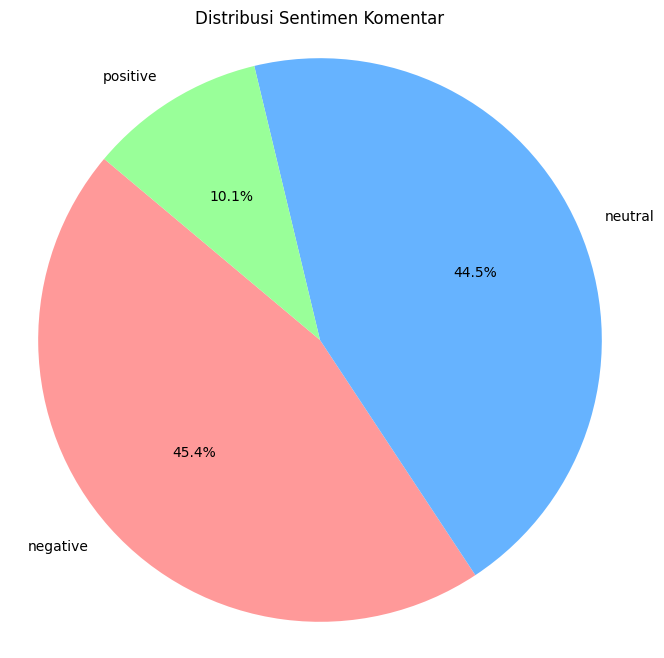

In [41]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribusi Sentimen Komentar')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

#EDA Sentimen

##Distribusi Sentimen

In [42]:
df['sentiment'].value_counts()

,count
sentiment,
negative,2870
neutral,2810
positive,641


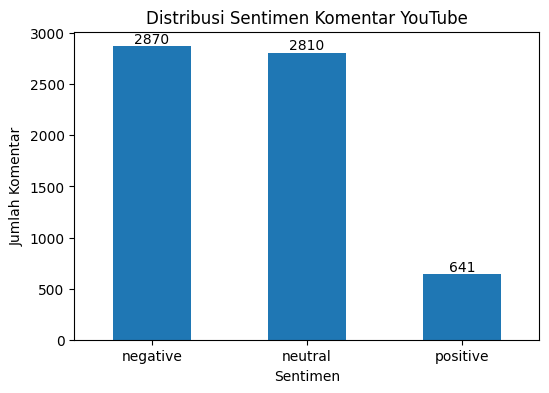

In [43]:
import matplotlib.pyplot as plt

ax = df['sentiment'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Distribusi Sentimen Komentar YouTube')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Komentar')
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0])

plt.show()

##WordCloud Positive

In [44]:
positive_text = ' '.join(
    df[df['sentiment']=='Positive']['stemming']
)

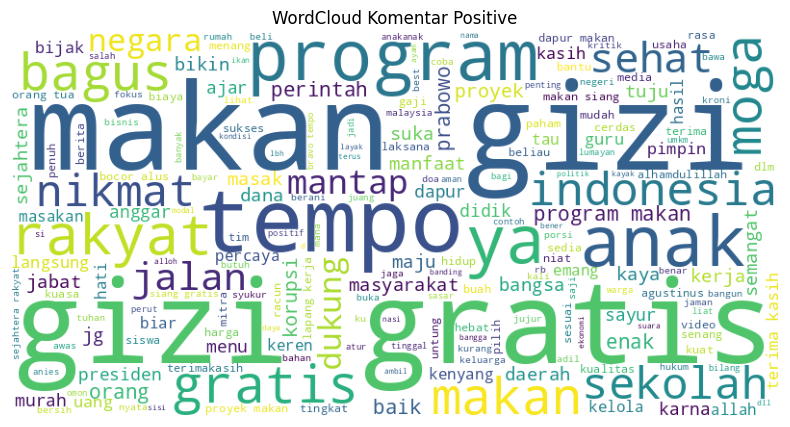

In [46]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Redefine positive_text with the correct casing 'positive'
positive_text = ' '.join(
    df[df['sentiment']=='positive']['stemming']
)

# Check if positive_text is still empty before generating wordcloud
if positive_text:
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(positive_text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title('WordCloud Komentar Positive')

    plt.show()
else:
    print("Tidak ada teks positif yang ditemukan untuk membuat word cloud.")

##WordCloud Negatif

In [50]:
negative_text = ' '.join(
    df[df['sentiment']=='negative']['stemming']
)

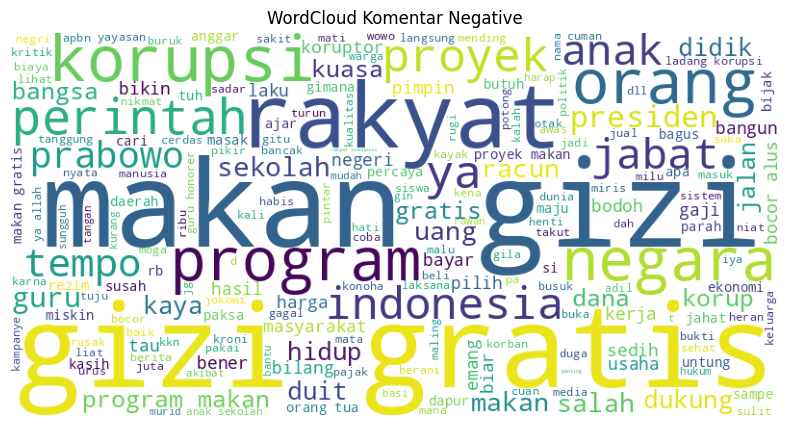

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Check if negative_text is empty before generating wordcloud
if negative_text:
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(negative_text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title('WordCloud Komentar Negative')

    plt.show()
else:
    print("Tidak ada teks negatif yang ditemukan untuk membuat word cloud.")

##Top Frequent Words

In [52]:
from collections import Counter
all_words = ' '.join(
    df['stemming']
).split()

In [53]:
word_freq = Counter(all_words)

word_freq.most_common(20)

[('makan', 2622),
 ('gratis', 2188),
 ('gizi', 2056),
 ('program', 923),
 ('tempo', 738),
 ('proyek', 719),
 ('rakyat', 681),
 ('korupsi', 601),
 ('orang', 586),
 ('anak', 561),
 ('negara', 512),
 ('perintah', 497),
 ('indonesia', 496),
 ('ya', 474),
 ('sekolah', 456),
 ('prabowo', 438),
 ('guru', 322),
 ('presiden', 318),
 ('uang', 295),
 ('jabat', 274)]

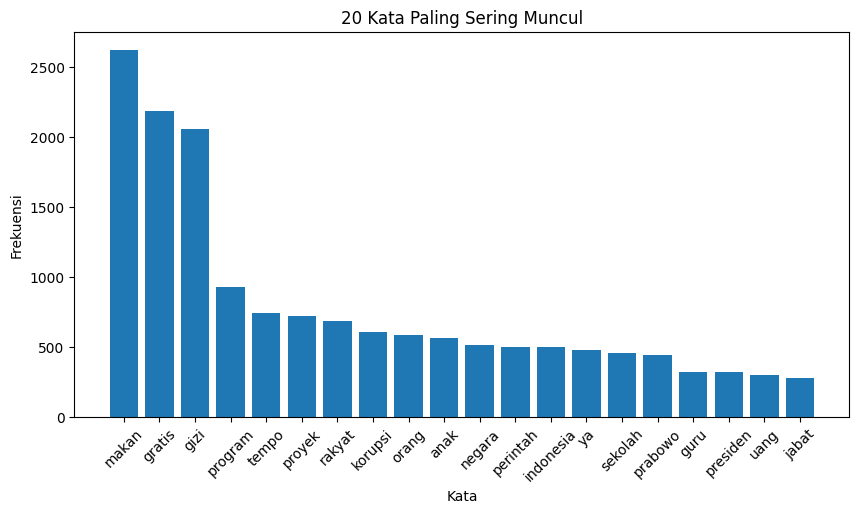

In [54]:
top_words = word_freq.most_common(20)

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]


plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title('20 Kata Paling Sering Muncul')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')

plt.xticks(rotation=45)

plt.show()

##Bigram / Trigram

In [55]:
from nltk.util import ngrams
from collections import Counter

###Bigram

In [56]:
tokens = ' '.join(df['stemming']).split()
bigram = list(ngrams(tokens,2))
bigram_freq = Counter(bigram)
bigram_freq.most_common(10)

[(('makan', 'gizi'), 1830),
 (('gizi', 'gratis'), 1747),
 (('program', 'makan'), 258),
 (('proyek', 'makan'), 175),
 (('makan', 'gratis'), 143),
 (('bocor', 'alus'), 119),
 (('orang', 'tua'), 116),
 (('gratis', 'makan'), 105),
 (('guru', 'honorer'), 80),
 (('gratis', 'program'), 71)]

###Trigram

In [57]:
trigram = list(ngrams(tokens,3))
trigram_freq = Counter(trigram)
trigram_freq.most_common(10)

[(('makan', 'gizi', 'gratis'), 1733),
 (('program', 'makan', 'gizi'), 223),
 (('proyek', 'makan', 'gizi'), 141),
 (('gizi', 'gratis', 'makan'), 78),
 (('gizi', 'gratis', 'program'), 65),
 (('gratis', 'makan', 'gizi'), 53),
 (('dapur', 'makan', 'gizi'), 49),
 (('gizi', 'gratis', 'proyek'), 47),
 (('makan', 'siang', 'gratis'), 42),
 (('dana', 'makan', 'gizi'), 30)]

#Feature Engineering

##TF-IDF

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['stemming'])
y = df['sentiment']

print(X.shape)

(6321, 10194)


artinya terdapat 6034 komentar dan 4287 kata unik (fitur)

In [61]:
# melihat nama fitur
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

['aaa' 'aaaa' 'aaaaa' 'aaaah' 'aaahhh' 'aaahhhh' 'aadalah' 'aamiiin'
 'aamiin' 'aassuuuuuuuu' 'aauu' 'abad' 'abadi' 'abah' 'abahgua' 'abai'
 'abal' 'abalabal' 'abaljustru' 'abang']


In [62]:
#melihat nilai TF-IDF
import pandas as pd

tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,aaa,aaaa,aaaaa,aaaah,aaahhh,aaahhhh,aadalah,aamiiin,aamiin,aassuuuuuuuu,...,zeonis,zero,zerrr,zhalim,zionis,zkowie,zolim,zolimi,zonk,zulkifli
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#Modeling

## Split Data

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Naive Bayes

In [64]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

##Logistic Regression

In [65]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

#Model Evaluation

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

##Evaluasi Naive Bayes

In [67]:
y_pred_nb = nb.predict(X_test)

In [68]:
print("=== Naive Bayes ===")

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_nb, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_nb))

=== Naive Bayes ===
Accuracy : 0.6624505928853754
Precision: 0.6956604124082554
Recall   : 0.6624505928853754
F1 Score : 0.6300984091025564

Classification Report
              precision    recall  f1-score   support

    negative       0.67      0.76      0.71       575
     neutral       0.65      0.70      0.68       562
    positive       1.00      0.02      0.05       128

    accuracy                           0.66      1265
   macro avg       0.77      0.50      0.48      1265
weighted avg       0.70      0.66      0.63      1265



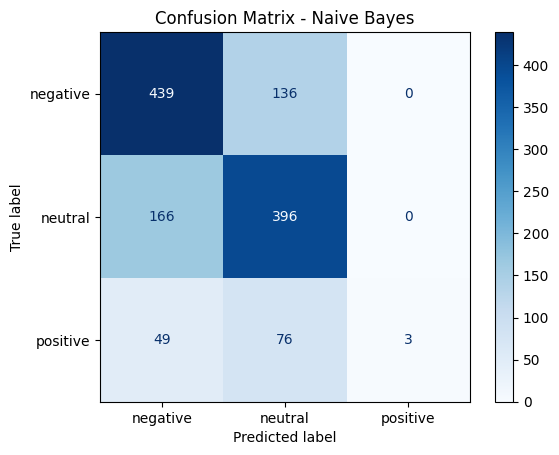

In [69]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=nb.classes_
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

##Evaluasi Logistic Regresion

In [70]:
y_pred_lr = lr.predict(X_test)

In [71]:
print("=== Logistic Regression ===")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_lr, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy : 0.6932806324110672
Precision: 0.7037483446905074
Recall   : 0.6932806324110672
F1 Score : 0.6784974533766656

Classification Report
              precision    recall  f1-score   support

    negative       0.71      0.73      0.72       575
     neutral       0.67      0.77      0.71       562
    positive       0.81      0.20      0.33       128

    accuracy                           0.69      1265
   macro avg       0.73      0.57      0.59      1265
weighted avg       0.70      0.69      0.68      1265



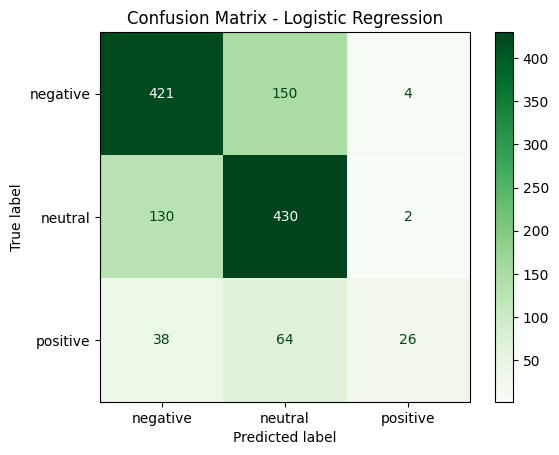

In [72]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr.classes_
)

disp.plot(cmap='Greens')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

##Perbandingan

In [73]:
import pandas as pd

hasil = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb, average='weighted'),
        precision_score(y_test, y_pred_lr, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_lr, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted')
    ]
})

hasil

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.662451,0.695660,0.662451,0.630098
1,Logistic Regression,0.693281,0.703748,0.693281,0.678497


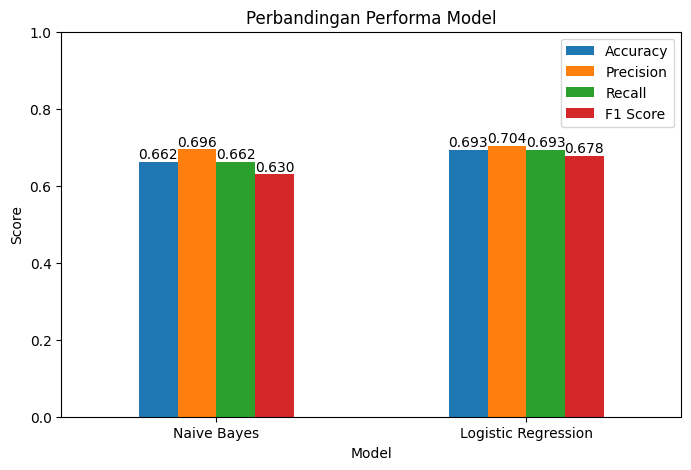

In [74]:
ax = hasil.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Perbandingan Performa Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.show()

#Deployment

In [75]:
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [76]:
joblib.dump(lr, 'logistic_regression.pkl')

['logistic_regression.pkl']